# Implementing the A-star algorithm (50 pts)

In this coding assignment, you will implement the A-star algorithm to search a maze. A maze is represented as an array of 0s and 1s. A cell in the maze is occupied if it is marked "1" and unoccupied if it is marked "0". The A-star algorithm will find the shortest path from A to B. The maze, along with the start and end positions are listed in the main() function.

A few IMPORTANT notes:
- A position in the maze is given by (x,y). As in lecture, x is the horizontal position along the maze, and y is the vertical position.
- Indexing in python starts from 0. Thus, in the given maze, (0,0) represents the bottom left cell and (9,9) represents the top right cell. As another example, (9,0) represents the right most cell at the bottom.
- For simplicity, we will make A-star find the shortest path in the maze from A to B. Thus, the cost l(x, x') associated with an edge between x and x' will simply be 1.

We have provided a number of helper functions for you (see below) and have also completed some portions of the code. You will complete the portions marked "TO DO". The code will return a path from A to B that avoids the obstacle cells. It may be helpful to refer to the slides from Lecture 7 posted on Canvas; the slides contain pseudocode.



In [1]:
############################## DO NOT MODIFY (but please read) ##############################################
# 헬퍼 함수들

class Vertex():
    """A class for vertices"""

    def __init__(self, parent=None, position=None):
        self.parent = parent      # 부모 vertex (경로 역추적용)
        self.position = position  # (x, y) 좌표

        self.C = float('inf')     # cost-to-come 초기값: 무한대
        self.H = 0                 # heuristic 초기값
        self.F = float('inf')     # F = C + H 초기값: 무한대

    def __eq__(self, other):      # "vertex_1 == vertex_2"로 두 vertex 비교 가능하게 함
        return self.position == other.position   # 위치(position)가 같으면 같은 vertex로 취급


def getNeighbors(x_vertex, maze):
    """x_vertex의 이웃(상하좌우)을 반환"""
    neighbors = []
    for new_position in [(-1, 0), (0, 1), (1, 0), (0, -1)]:  # 좌, 상, 우, 하 순서로 확인
        vertex_position = (x_vertex.position[0] + new_position[0],
                            x_vertex.position[1] + new_position[1])  # 이웃 후보의 좌표 계산

        # 미로 범위(0~9)를 벗어나면 건너뜀
        if vertex_position[0] > (len(maze) - 1) or vertex_position[0] < 0 \
           or vertex_position[1] > (len(maze[len(maze)-1]) - 1) or vertex_position[1] < 0:
            continue

        # 그 위치가 장애물(1)이면 건너뜀 (배열 인덱싱이 y축 뒤집혀 있어 len(maze)-y-1)
        if maze[len(maze) - vertex_position[1] - 1][vertex_position[0]] != 0:
            continue

        new_vertex = Vertex(None, vertex_position)  # 통과했으면 새 vertex 객체 생성
        neighbors.append(new_vertex)                 # 이웃 목록에 추가

    return neighbors
############################################################################################################


################ TO DO: FILL THIS IN #####################################################
def GetBestVertex(Q):
    """Q 안에서 F값이 가장 작은 vertex를 찾아 반환"""
    best_idx = 0             # 일단 0번째를 최선이라고 가정
    best_F = Q[0].F           # 0번째 vertex의 F값을 기준으로 저장

    for i, v in enumerate(Q):    # Q의 모든 vertex를 인덱스(i)와 함께 순회
        if v.F < best_F:          # 지금 F가 지금까지의 최솟값보다 작으면
            best_F = v.F           # 최솟값 갱신
            best_idx = i            # 그 위치도 갱신

    x_vertex = Q[best_idx]    # 최종적으로 F가 가장 작은 vertex 객체
    x_index = best_idx        # Q 안에서의 위치 (나중에 pop할 때 필요)
    return x_vertex, x_index


def computeH(vertex, B_vertex):
    """휴리스틱 H(vertex): vertex에서 목표(B_vertex)까지의 Euclidean distance (admissible)"""
    dx = vertex.position[0] - B_vertex.position[0]   # x좌표 차이
    dy = vertex.position[1] - B_vertex.position[1]   # y좌표 차이
    return (dx**2 + dy**2) ** 0.5                      # 피타고라스로 직선거리 계산
##########################################################################################


######### A* 알고리즘 본체 #########
def astar(maze, A, B):
    """미로(maze)에서 A부터 B까지의 경로를 리스트로 반환"""

    ############################## DO NOT MODIFY ##############################################
    # 시작/목표 vertex 생성
    A_vertex = Vertex(None, A)
    B_vertex = Vertex(None, B)
    A_vertex.C = 0                               # 시작점의 cost-to-come = 0
    A_vertex.H = computeH(A_vertex, B_vertex)    # 시작점의 휴리스틱 계산
    A_vertex.F = A_vertex.H                        # F = C + H = 0 + H

    # Q(Alive 집합)와 DeadSet(확정된 노드) 초기화
    Q = []
    Q.append(A_vertex)     # 시작점을 큐에 넣음
    DeadSet = []
    ############################################################################################

    # 큐가 빌 때까지 반복
    while len(Q) > 0:

        ################ GetBestVertex(Q) 사용 #####################################
        # 현재 vertex: F가 가장 작은 것을 꺼냄
        x_vertex, x_index = GetBestVertex(Q)
        ########################################################################################

        ################### DO NOT MODIFY THIS ##############################################
        # 목표 B에 도달했는지 확인
        if x_vertex == B_vertex:
            # 도달했으면 parent를 따라 역추적해서 경로 복원
            path = []
            current = x_vertex
            while current is not None:
                path.append(current.position)
                current = current.parent
            return path[::-1]   # 뒤집어서 A→B 순서로 반환
        #####################################################################################

        ########################### Q에서 제거하고 DeadSet에 추가 ############################
        Q.pop(x_index)             # 현재 노드를 Q(Alive)에서 제거
        DeadSet.append(x_vertex)    # DeadSet(확정)에 추가 → 이제 이 노드는 "Dead"
        #####################################################################################

        ################### DO NOT MODIFY THIS ##############################################
        # 이웃 노드들 생성
        neighbors = getNeighbors(x_vertex, maze)
        #####################################################################################

        # 이웃들을 순회하며 비용 갱신 (Resolve Duplicate 로직)
        for x_prime in neighbors:

            if x_prime in DeadSet:      # 이미 확정(Dead)된 노드면
                continue                 # 더 볼 필요 없이 다음 이웃으로

            tentative_C = x_vertex.C + 1   # x_vertex를 거쳐 x_prime까지 가는 비용 후보 (edge 비용 1)

            # x_prime이 이미 Q(Alive) 안에 있는지 확인
            in_Q = None
            for q_vertex in Q:
                if q_vertex == x_prime:     # 위치가 같은 vertex를 찾으면
                    in_Q = q_vertex
                    break

            if in_Q is None:                 # 처음 발견된 노드라면 (Unvisited → Alive)
                x_prime.parent = x_vertex              # 부모 기록
                x_prime.C = tentative_C                 # cost-to-come 설정
                x_prime.H = computeH(x_prime, B_vertex)  # 휴리스틱 계산
                x_prime.F = x_prime.C + x_prime.H       # F = C + H
                Q.append(x_prime)                        # Q에 새로 추가

            else:                             # 이미 Q에 있던 노드라면 (Resolve duplicate!)
                if tentative_C < in_Q.C:      # 이번 경로가 기존보다 더 싸면
                    in_Q.parent = x_vertex      # 부모 갱신 (더 싼 경로로 갈아탐)
                    in_Q.C = tentative_C         # cost-to-come 갱신
                    in_Q.F = in_Q.C + in_Q.H    # F 재계산 (H는 위치 불변이라 그대로)
                # 더 싸지 않으면 아무것도 하지 않음 — 기존 경로가 이미 더 좋음

    return None   # Q가 비었는데 goal을 못 찾음 → 경로 없음 (FAILURE)
##############################################################################################


############################## DO NOT MODIFY ##############################################
# 테스트용 미로 (0=자유공간, 1=장애물)
maze = [[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]]

A = (0, 0)   # 시작점
B = (7, 6)   # 목표점

path = astar(maze, A, B)   # A* 실행
print(path)                 # 결과 경로 출력
############################################################################################

[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (6, 3), (7, 3), (8, 3), (8, 4), (9, 4), (9, 5), (9, 6), (8, 6), (7, 6)]


The cell below will visualize the path that your A-star implementation found. Obstacles are colored in purple, free cells are yellow, and the path is shown in green.

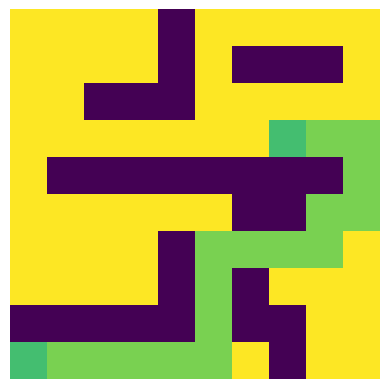

In [2]:
# This cell visualizes the path you found above
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

maze_modified = 1.0 - np.array(maze)
for v in path:
    maze_modified[len(maze)-v[1]-1][v[0]] = 0.8
maze_modified[len(maze)-A[1]-1][A[0]] = 0.7
maze_modified[len(maze)-B[1]-1][B[0]] = 0.7

plt.imshow(maze_modified); # , cmap='hot');
plt.axis('off');
